# WA Assignement

Due date: 03/01/25 23:00


* mohamedali.benbelhassen@edhec.com - Cohort A
* lorenzo.ciampana@edhec.com - Cohort B
* gianluca.filesi@edhec.com - Cohort B
* giacomo.nube@edhec.com - Cohort A

## Guidelines

Based on the demo dataset, for all of January 2021, you need to provide 4 business problems regarding the dataset.
For each one, you need to frame a problem regarding the data, and explain clearly your reasoning.

Constraints :
* All of them must include an SQL query (or several!)
* At least 2 of them must include a statistical test to prove (or not) your point
* At least 2 of them must include a Window function. (Come usare le window functions: [Link](https://medium.com/google-cloud/bigquery-window-functions-advanced-techniques-for-data-professionals-e0a6ca3f9502))
* All of them must include a dataviz

If, in the end, you don’t reach statistical significance, this is fine 👍 as long as the test is statistically rigorous.


### Grade
* Clean and commented SQL queries
* Statistical tests explained step by step
* Data cleanup can be done in SQL or Python if needed, but must be commented very clearly
* Pimp your dataviz
* In case you use ChatGPT, this is absolutely fine, but you must share the prompts (they will be graded!)

Grades :
* Overall complexity of the insights chosen : 5 pts
* Complexity and clarity of SQL queries : 3 pts
* Dataviz : 3 pts
* Stats : 3 pts
* Explanations & clarity of the whole document : 3 pts
* Prompting quality : 2 pts
* Jokes, use of emoji, memes : 1 pt


### Examples:
* Does time of day influence conversion rate?
* What product categories have the highest “add to cart to order” rate?
* Are regular users more likely to purchase?

## Cosa manca

* Test domanda 2
* Quarta domanda: un test e possibilmente un'altra window function
* Data cleanup can be done in SQL or Python if needed, but must be commented very clearly
* Prompts



## Intro

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
client = bigquery.Client(project='axial-acrobat-443013-n7')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import ttest_ind
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# When during the day do our customers prefer buying our product?
Understanding when customers make purchases can reveal a lot about their habits and preferences. For example, morning purchases might show that people are shopping for practical or planned items, while evening purchases could be more spontaneous. During the week, people might shop during work breaks, whereas on weekends, they might take more time to browse. This information can help businesses improve strategies, like running promotions at the right time or making the shopping experience easier when people are most active. It also helps with planning inventory, predicting demand, and personalizing recommendations to match customer behaviors, making the business more efficient and customer-focused.

## Code

In [18]:
# Example lo rinominerei - GF
Example = client.query('''
SELECT
  EXTRACT(HOUR FROM TIMESTAMP_MICROS(event_timestamp)) as hour,
  event_value_in_usd as transaction_value
FROM
  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_202101*`
WHERE
  event_name = 'purchase'
AND event_value_in_usd IS NOT null
''').to_dataframe()
Example['hour'] = Example['hour'].astype(float)
Example['transaction_value'] = Example['transaction_value'].astype(float)
print(Example)

     hour  transaction_value
0     3.0               96.0
1     4.0               44.0
2     4.0               44.0
3     4.0               44.0
4    13.0               44.0
..    ...                ...
899   0.0               81.0
900   7.0              100.0
901  12.0              239.0
902  17.0               63.0
903  11.0              355.0

[904 rows x 2 columns]


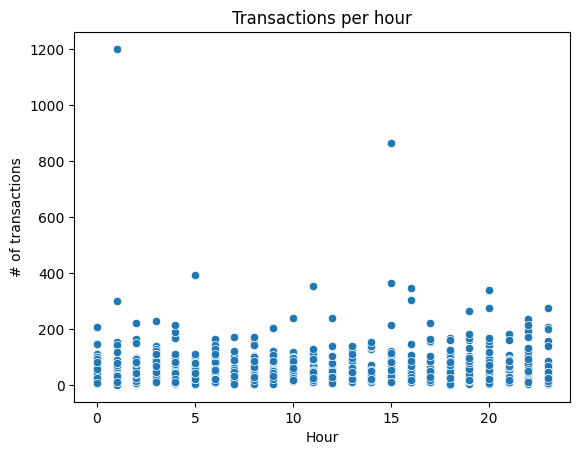

In [5]:
sns.scatterplot(data=Example, x='hour', y='transaction_value')
plt.title('Transactions per hour')
plt.xlabel('Hour')
plt.ylabel('# of transactions')
plt.show()

In [6]:
correlation = Example['hour'].corr(Example['transaction_value'])
print("The correlation coefficient between 'hour' and 'transaction_value':", correlation)

The correlation coefficient between 'hour' and 'transaction_value': -0.00915917022312917


## Conclusions
The correlation coefficient between the hour of the day and the number of transactions is -0.0092, indicating almost no linear relationship between the two variables. This suggests that the time of day alone does not have a strong direct impact on the number of transactions.

However, the graph shows distinct spikes in transactions at specific hours, particularly around 15:00 and midnight, which may not be captured by the correlation coefficient. These patterns could be influenced by other factors, such as customer routines, promotions, or external events.

The lack of overall correlation reinforces the importance of focusing on specific patterns or peaks in the data, rather than expecting a consistent trend across all hours. The sharp spike at 15:00, for example, could represent a key opportunity for targeted marketing, even if the overall relationship between time and transactions is weak.

![DALL·E 2024-12-29 11.08.29 - A humorous cartoon-style depiction of a nerdy person sitting at their desk at midnight, lit only by the glow of their computer screen. They wear thick.webp]he(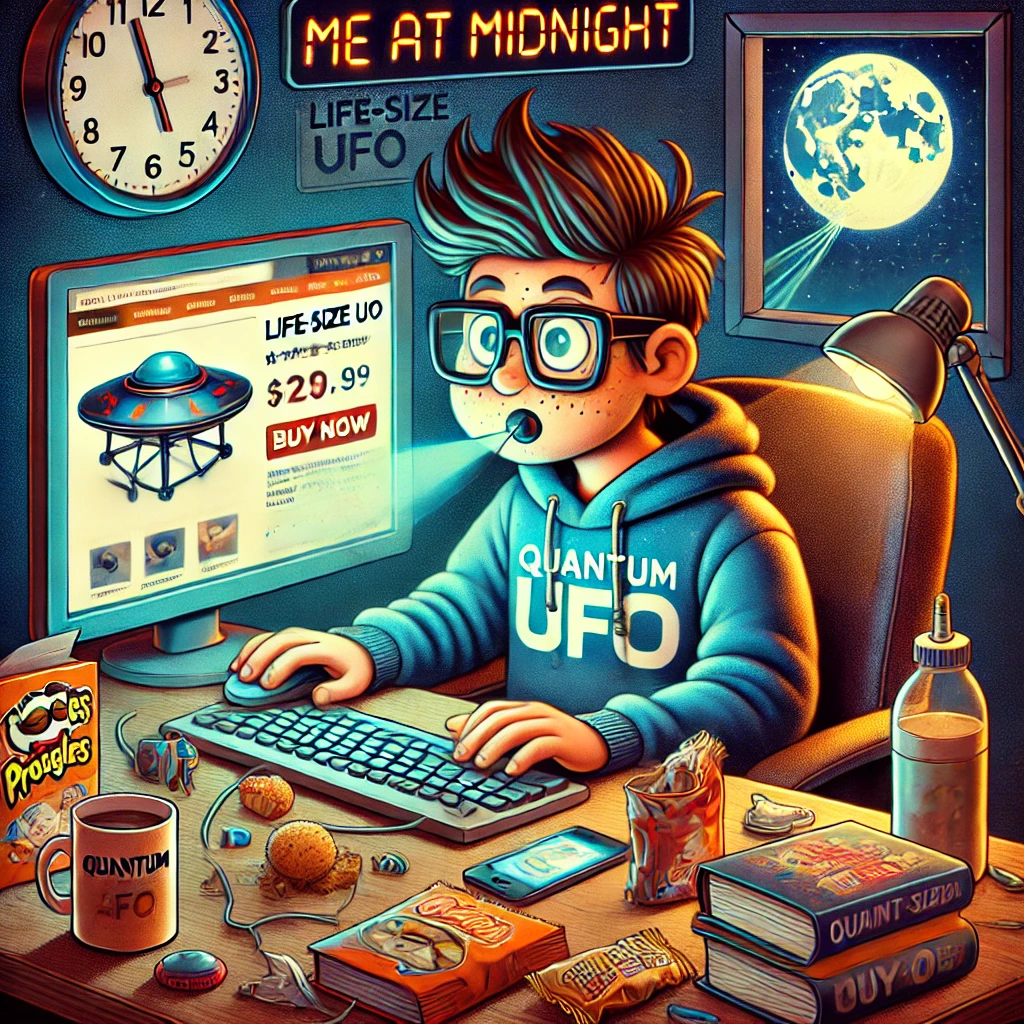)

# Do discounts views increase the willingness to purchase per day?
Analyzing the trend between discount page views and purchases per day is essential to measure how effectively discounts drive sales. A strong correlation indicates that discounts convert interest into purchases, while a weak link suggests potential issues like unattractive offers, unclear messaging, or a mismatch between discounts and customer needs. This analysis helps optimize discount strategies, identify the best timing for promotions, and refine the user experience to reduce barriers to purchase. It also supports better forecasting, ensuring resources like inventory and marketing are aligned with demand, ultimately improving overall sales performance.


In [7]:
discount_data = client.query('''
SELECT
  event_date,
  SUM(CASE WHEN event_name = 'view_promotion' THEN 1 ELSE 0 END) AS view_promotion,
  SUM(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS purchase
FROM
  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_202101*`
WHERE
  event_name IN ('view_promotion', 'purchase')
GROUP BY
  event_date
ORDER BY
  event_date ASC;
''').to_dataframe()

print(discount_data)

   event_date  view_promotion  purchase
0    20210101             798        14
1    20210102             948        14
2    20210103             953        14
3    20210104            1265        16
4    20210105            2278        29
5    20210106            3830        31
6    20210107            2324        26
7    20210108            1923        34
8    20210109            1337        20
9    20210110            1171        14
10   20210111            1753        28
11   20210112            2377        48
12   20210113            2127        36
13   20210114            1975        54
14   20210115            1649        47
15   20210116            1233        27
16   20210117            1075        14
17   20210118            1440        19
18   20210119            1950        49
19   20210120            2390        96
20   20210121            1940        52
21   20210122            1931       100
22   20210123            1477        43
23   20210124            1342        36


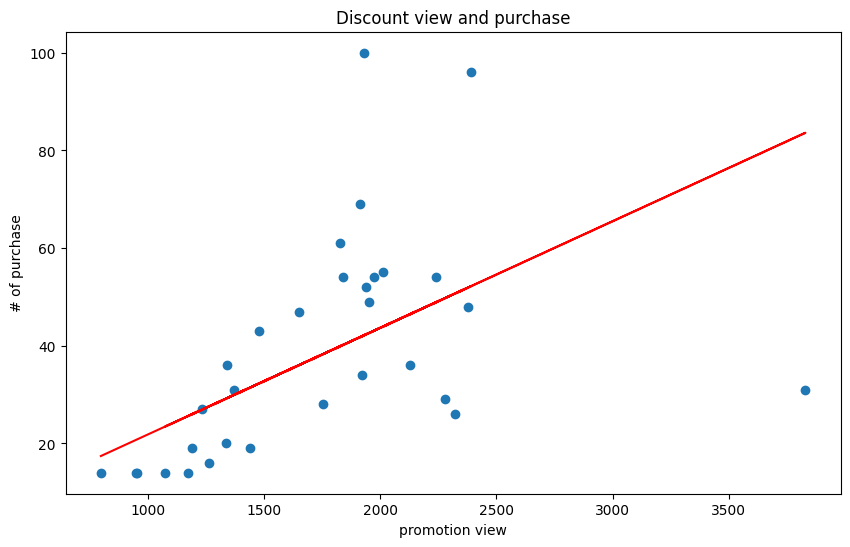

In [8]:
X1 = discount_data['view_promotion']
Y1 = discount_data['purchase']
model1 = sm.OLS(Y1, X1).fit()
discount_data['Fitted_values_model1'] = model1.predict(X1)

plt.figure(figsize=(10, 6))
plt.scatter(discount_data['view_promotion'], discount_data['purchase'], label='Data')
plt.plot(discount_data['view_promotion'], discount_data['Fitted_values_model1'], color='red', label='Fitted Regression Line')
plt.title('Discount view and purchase')
plt.xlabel('promotion view')
plt.ylabel('# of purchase')
plt.show()

In [9]:
correlation_q2 = discount_data['view_promotion'].corr(discount_data['purchase'])
print("The correlation coefficient between 'hour' and 'transaction_value':", correlation_q2)

The correlation coefficient between 'hour' and 'transaction_value': 0.4649394582294055


In [10]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:               purchase   R-squared (uncentered):                   0.804
Model:                            OLS   Adj. R-squared (uncentered):              0.797
Method:                 Least Squares   F-statistic:                              122.7
Date:                Sun, 29 Dec 2024   Prob (F-statistic):                    4.00e-12
Time:                        09:57:31   Log-Likelihood:                         -136.58
No. Observations:                  31   AIC:                                      275.2
Df Residuals:                      30   BIC:                                      276.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
view_promotion     0.0218      0.002     11.078      0.000       0.018       0.026
==============================================================================
Omnibus:                        6.133   Durbin-Watson:                   0.959
Prob(Omnibus):                  0.047   Jarque-Bera (JB):                5.932
Skew:                           0.432   Prob(JB):                       0.0515
Kurtosis:                       4.961   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Conclusion
The scatter plot and correlation coefficient (0.4649) reveal a moderate positive relationship between discount page views and purchases, indicating that increased views generally lead to higher sales. However, the trend is not perfectly linear, suggesting that other factors, such as the attractiveness of discounts or external influences, also play a role. This highlights the importance of increasing discount visibility to boost sales while investigating deviations to refine promotional strategies

# Where do we sell the most quantity of product and it is related to revenues?
Understanding where the highest profits are generated and analyzing the relationship between ordered quantities and profit is essential for a company's success. Identifying the most profitable regions or market segments enables businesses to optimize resources. Simultaneously, examining the relationship between order quantities and profit helps evaluate pricing strategies, uncovering opportunities to maximize earnings and improve business sustainability. These data-driven insights empower more informed decisions and foster targeted business growth.

In [11]:
revenue_data = client.query('''
WITH region_rankings_revenue AS (
    SELECT
        geo.country AS Country,
        geo.region AS Region,
        SUM(ecommerce.purchase_revenue) AS total_revenue
    FROM
        `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    GROUP BY
        geo.country, geo.region
)
SELECT
    Country,
    Region,
    total_revenue,
    AVG(total_revenue) OVER (PARTITION BY Country) AS avg_revenue_country
FROM
    region_rankings_revenue
ORDER BY
    total_revenue DESC;
''').to_dataframe()

print(revenue_data.head(16))

           Country            Region  total_revenue  avg_revenue_country
0    United States        California        35318.0          3211.460000
1    United States             Texas        15101.0          3211.460000
2           Canada           Ontario        12769.0          2981.727273
3    United States          Virginia         9859.0          3211.460000
4   United Kingdom           England         9652.0          2291.600000
5    United States           Florida         9199.0          3211.460000
6           Canada  British Columbia         7794.0          2981.727273
7    United States          New York         7057.0          3211.460000
8           Canada            Quebec         7017.0          2981.727273
9    United States        New Jersey         6338.0          3211.460000
10   United States     Massachusetts         6193.0          3211.460000
11           India       Maharashtra         5100.0          1521.130435
12   United States          Illinois         5007.0

In [12]:
quantity_data = client.query('''
WITH region_rankings_quantity AS (
    SELECT
        geo.country AS Country,
        geo.region AS Region,
        SUM(ecommerce.total_item_quantity) AS total_quantity,
    FROM
        `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    GROUP BY
        geo.country, geo.region
)
SELECT
    Country,
    Region,
    total_quantity,
    AVG(total_quantity) OVER (PARTITION BY Country) AS avg_quantity_country
FROM
    region_rankings_quantity
ORDER BY
    total_quantity DESC;
''').to_dataframe()

print(quantity_data.head(16))

           Country            Region  total_quantity  avg_quantity_country
0    United States              Ohio      2422597798          4.659225e+07
1   United Kingdom  Northern Ireland       100000103          2.023862e+07
2   United Kingdom           England         1192630          2.023862e+07
3    United States        California          121324          4.659225e+07
4            India           Haryana           19884          1.615333e+03
5           Canada           Ontario           16120          2.439455e+03
6    United States           Florida            7946          4.659225e+07
7           Taiwan       Taipei City            7872          1.343000e+03
8    United States             Texas            7014          4.659225e+07
9    United States          New York            6289          4.659225e+07
10   United States          Virginia            5687          4.659225e+07
11   United States     Massachusetts            5642          4.659225e+07
12          Canada       

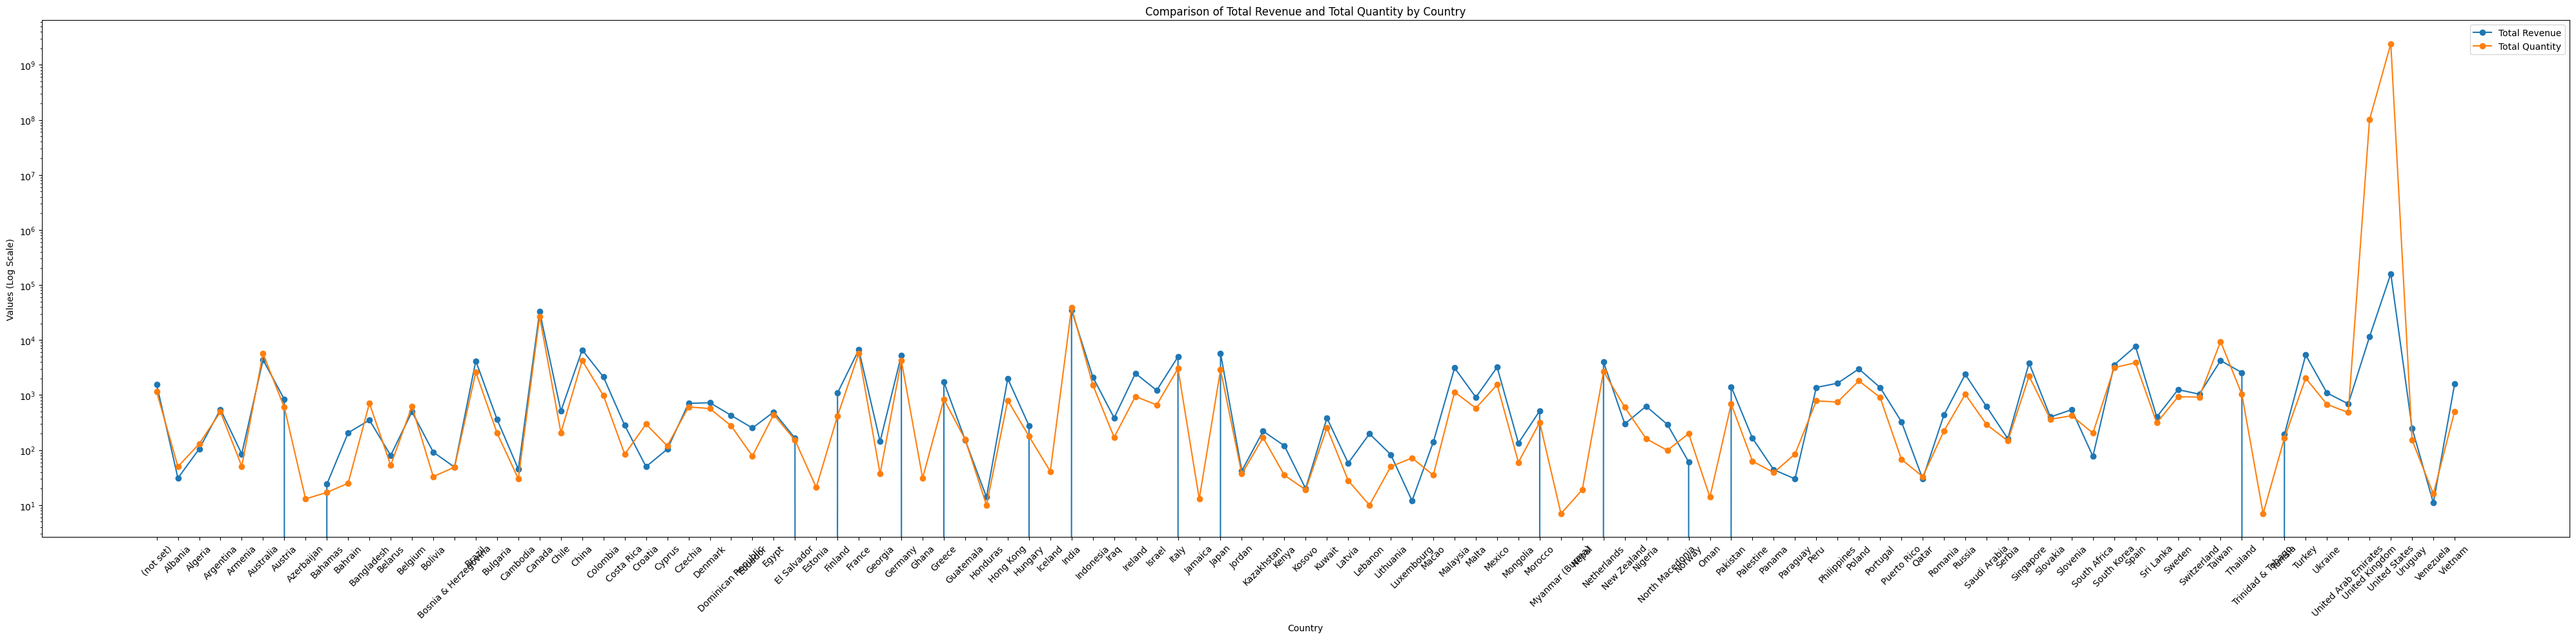

In [13]:
# Aggregate data and drop NaN values otherwise there could be some kind of problem in data visualization and also during the statistical test
revenue_by_country = revenue_data.groupby("Country")["total_revenue"].sum().reset_index()
quantity_by_country = quantity_data.groupby("Country")["total_quantity"].sum().reset_index()

# Merge data by country
merged_country_df = pd.merge(revenue_by_country, quantity_by_country, on="Country", how="inner")

# Plot Total Revenue and Total Quantity
plt.figure(figsize=(40, 10))
plt.plot(merged_country_df['Country'], merged_country_df['total_revenue'], label='Total Revenue', marker='o')
plt.plot(merged_country_df['Country'], merged_country_df['total_quantity'], label='Total Quantity', marker='o')
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Values (Log Scale)') # Using log scale for better visualization
plt.yscale('log')
plt.title('Comparison of Total Revenue and Total Quantity by Country')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

In most countries, there is a clear positive relationship between total revenue and total quantity sold. This correlation aligns with basic economic principles, such as the law of demand, which suggests that as more units are sold, total revenue typically increases if prices remain stable or decrease slightly.

In contrast, some countries display a mismatch between total revenue and total quantity sold, driven by various economic and market factors. In regions where quantities are high but revenues are comparatively low, products may be sold at lower price points to cater to price-sensitive consumers. This trend is common in developing economies, where affordability often dictates pricing strategies.

Conversely, countries with high revenue but low quantity figures may focus on premium or high-margin products, where fewer sales generate substantial revenue due to higher prices. These discrepancies can also result from differences in market structure—such as intense competition leading to lower prices—or consumer preferences, where demand for luxury or necessity goods sustains high pricing regardless of sales volume.

# Seasonality for revenue
Unfortunately, we are unable to verify seasonality due to the limited historical data available in the dataset. The available data covers too short a time period to identify significant trends related to seasonality.

In [14]:
MaxMinDate_data = client.query('''
SELECT
    MIN(PARSE_DATE('%Y%m%d', event_date)) AS earliest_date,
    MAX(PARSE_DATE('%Y%m%d', event_date)) AS latest_date
FROM
    `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`;
''').to_dataframe()

print(MaxMinDate_data)

  earliest_date latest_date
0    2020-11-01  2021-01-31


Thanks ChatGPT with promt "How can we create seasonality using EVENT_DATE(YYYYMMDD)?" we got the code to group al the revenue for each month shown in the dataset analysed, moreover we descover the PARSE_DATE comand that is useful when you have a column or string value representing a date in a non-standard format, and you want to convert it into a DATE type to facilitate calculations, filtering, and temporal groupings.

In [15]:
SeasonalityDate_data = client.query('''
SELECT
    EXTRACT(YEAR FROM PARSE_DATE('%Y%m%d', event_date)) AS year,
    EXTRACT(MONTH FROM PARSE_DATE('%Y%m%d', event_date)) AS month,
    SUM(ecommerce.purchase_revenue) AS total_revenue
FROM
    `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE
    ecommerce.purchase_revenue IS NOT NULL
GROUP BY
    year, month
ORDER BY
    year, month;
''').to_dataframe()

print(SeasonalityDate_data)

   year  month  total_revenue
0  2020     11       144260.0
1  2020     12       160555.0
2  2021      1        57350.0


# What is the total number of events recorded for each day, and how do the days rank based on the total number of events?

Since we cannot do it with month and years for the revenue, we tried do figure out "What is the total number of events recorded for each day, and how do the days rank based on the total number of events?" because understanding the total number of events recorded for each day helps identify trends and seasonality, such as recurring traffic spikes on specific days, holidays, or during special promotions. This insight allows businesses to better plan marketing campaigns and optimize resources.

In [16]:
DailyEvents_data = client.query('''
WITH daily_event AS (
    SELECT
        PARSE_DATE('%Y%m%d', event_date) AS event_date, -- event_date in DATE type
        COUNT(*) AS total_events -- count the total events per day
    FROM
        `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    GROUP BY
        event_date
)
SELECT
    event_date,
    total_events,
    RANK() OVER (ORDER BY total_events DESC) AS event_rank -- ranking of the days based on the number of events
FROM
    daily_event
ORDER BY
    event_rank;
''').to_dataframe()

print(DailyEvents_data.head(30))

    event_date  total_events  event_rank
0   2020-12-08         92199           1
1   2020-12-09         82315           2
2   2020-12-10         80855           3
3   2020-12-11         75780           4
4   2020-12-15         72774           5
5   2020-12-01         71804           6
6   2020-12-03         71689           7
7   2020-12-07         71632           8
8   2020-11-30         70614           9
9   2020-12-04         69393          10
10  2020-12-16         67497          11
11  2020-12-02         66832          12
12  2020-12-14         66082          13
13  2020-11-25         64469          14
14  2021-01-20         64109          15
15  2020-12-17         63887          16
16  2020-11-24         62971          17
17  2020-11-03         61672          18
18  2020-11-17         59789          19
19  2020-11-20         57894          20
20  2020-12-18         56742          21
21  2020-12-12         56146          22
22  2021-01-06         56076          23
23  2020-11-18  

## Conclusions
The analysis revealed that the majority of the top 30 days with the highest event activity occurred in December, with the first 10 positions dominated by this month. This is likely due to seasonal promotions and discounts for Christmas presents, which successfully drove user engagement.

However, a significant decline in activity was observed after December 25, indicating a post-holiday slowdown. This highlights an opportunity to extend engagement into late December and early January through targeted campaigns such as New Year promotions or clearance sales.

Overall, the findings emphasize the importance of leveraging early December as a peak period for driving traffic and conversions, while also addressing slower periods with tailored strategies to maintain momentum.